In [3]:
import gmplot
import pandas as pd
from staticmap import StaticMap, CircleMarker

In [4]:
data = pd.read_excel("auction_data.xlsx")
data.head(2)

,LOTTO,CODICE,LOCALITA,INDIRIZZO,CIVICO,ID,PREZZO BASE,PREZZO_AG,AGGIUDICATARIO,GIORNO,MESE,ANNO,BOX/P.A.,address,lat,lng
0,104/24,160147,MILANO,VIA GIOVANNI PASCOLI,'4,70,"€ 151.200,00","€ 351.771,10",S.G.,13,giugno,2024,NaN,"VIA GIOVANNI PASCOLI '4, MILANO",45.473843,9.218549
1,105/24,160165,MILANO,VIA GIOVANNI PASCOLI,'4,34,"€ 69.360,00","€ 210.000,00",S.A.M.,13,giugno,2024,NaN,"VIA GIOVANNI PASCOLI '4, MILANO",45.473843,9.218549


In [5]:
#the following raws will be filtered
data[data["lat"].isnull()]

,LOTTO,CODICE,LOCALITA,INDIRIZZO,CIVICO,ID,PREZZO BASE,PREZZO_AG,AGGIUDICATARIO,GIORNO,MESE,ANNO,BOX/P.A.,address,lat,lng
1494,LOTTO,CODICE,LOCALITA,INDIRIZZO,CIVICO,ID,PREZZO BASE ASTA,PREZZO AGGIUD.,AGGIUDICATARIO,21,luglio,2020,BOX/P.A.,"INDIRIZZO CIVICO, LOCALITA",NaN,NaN
1528,LOTTO,CODICE,LOCALITA,INDIRIZZO,CIVICO,ID,PREZZO BASE ASTA,PREZZO AGGIUD.,AGGIUDICATARIO,21,luglio,2020,BOX/P.A.,"INDIRIZZO CIVICO, LOCALITA",NaN,NaN


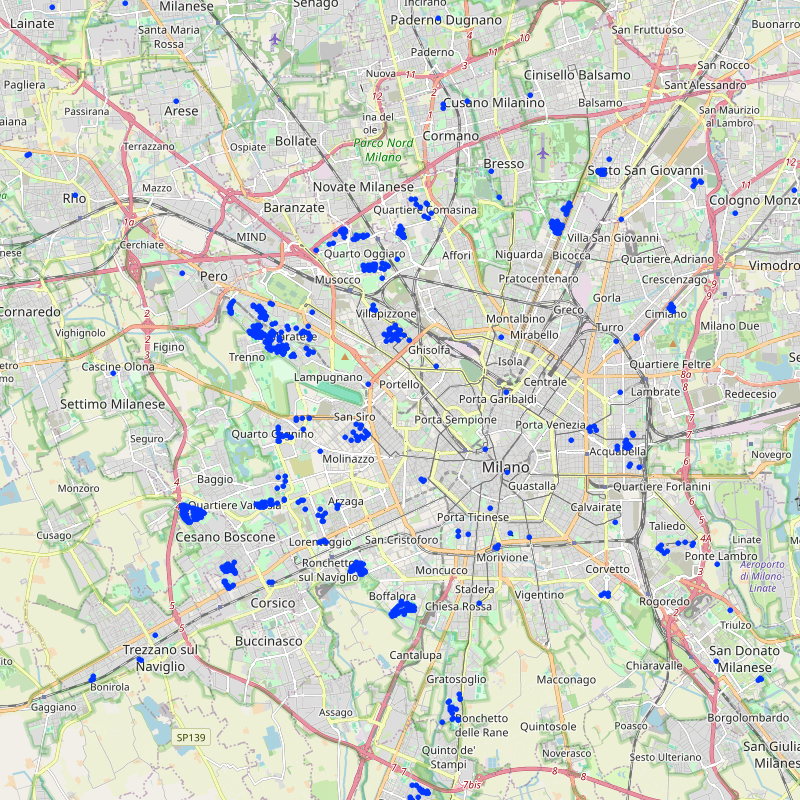

In [6]:
data = data[~data["lat"].isnull()]
c_lat =  data["lat"].mean()
c_lon = data["lng"].mean()

m = StaticMap(800, 800, background_color='gray')
for i, row in data.iterrows():
    marker = CircleMarker((row['lng'], row['lat']), '#0036FF', 5)
    m.add_marker(marker)

image = m.render(center=(c_lon, c_lat), zoom=12)
image.save('marker.png')
image

In [7]:
from sklearn.cluster import DBSCAN
clustering = DBSCAN(eps=0.05, min_samples=5).fit(data[['lat','lng']])
clustering.labels_

array([0, 0, 0, ..., 0, 0, 0], shape=(3411,))

In [8]:
import hdbscan
cls = hdbscan.HDBSCAN(min_cluster_size=20, metric='euclidean')
labels = cls.fit_predict(data[['lat','lng']])
print(set(labels))
data['labels'] = labels

{np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48), np.int64(49), np.int64(50), np.int64(51), np.int64(52), np.int64(53), np.int64(54), np.int64(55), np.int64(56), np.int64(-1)}


In [9]:
label_bicocca = set(data[data["address"].str.contains("SUZZANI")]["labels"])

In [33]:
#dati immobiliari quartiere biccocca dal 2024
data_bicocca = data[data['labels'].isin(label_bicocca)]
data_bicocca = data_bicocca[data_bicocca["ANNO"]>=2024].sort_values("ANNO")
data_bicocca.sort_values("PREZZO_AG", ascending=False).head(15)

,LOTTO,CODICE,LOCALITA,INDIRIZZO,CIVICO,ID,PREZZO BASE,PREZZO_AG,AGGIUDICATARIO,GIORNO,MESE,ANNO,BOX/P.A.,address,lat,lng,labels,PREZZO_AG_NUM
27,131/24,70590625,MILANO,VIA RAFFAELLO GIOLLI,'21,154,"€ 274.013,00","€ 423.600,00",T.A.,13,giugno,2024,70592625,"VIA RAFFAELLO GIOLLI '21, MILANO",45.526100,9.210574,15,"€ 423.600,00"
3367,025/24,70590584,MILANO,VIA BELTRAME CRISTIANI,'27,144,"€ 232.560,00","€ 379.784,00",M.C.,15,febbraio,2024,NaN,"VIA BELTRAME CRISTIANI '27, MILANO",45.523300,9.205649,15,"€ 379.784,00"
1947,160/24,70590820,MILANO,VIA RAFFAELLO GIOLLI,'28,141,"€ 246.468,00","€ 360.000,00",B. N.,19,settembre,2024,NaN,"VIA RAFFAELLO GIOLLI '28, MILANO",45.527347,9.210982,15,"€ 360.000,00"
3022,064/24,70590454,MILANO,VIALE GIOVANNI SUZZANI,'280,127,"€ 227.138,00","€ 356.999,00",A.M.,11,aprile,2024,70592454,"VIALE GIOVANNI SUZZANI '280, MILANO",45.526445,9.209225,15,"€ 356.999,00"
3023,065/24,70590848,MILANO,VIA RAFFAELLO GIOLLI,'24,119,"€ 206.599,00","€ 356.999,00",P.I.,11,aprile,2024,NaN,"VIA RAFFAELLO GIOLLI '24, MILANO",45.526893,9.211055,15,"€ 356.999,00"
3233,229/24,70590066,MILANO,VIA BELTRAME CRISTIANI,'9,122,"€ 233.410,00","€ 352.300,00",C.J.,28,novembre,2024,70592066,"VIA BELTRAME CRISTIANI '9, MILANO",45.522086,9.205586,15,"€ 352.300,00"
3366,024/24,70590224,MILANO,VIA ANTONIO LISSONI,'3,125,"€ 201.875,00","€ 349.459,18",C.S.,15,febbraio,2024,70592224,"VIA ANTONIO LISSONI '3, MILANO",45.522270,9.207153,15,"€ 349.459,18"
2920,182/25,70590889,MILANO,VIALE GIOVANNI SUZZANI,'243,103,"€ 237.121,00","€ 335.000,00",S.B.,27,novembre,2025,70592889,"VIALE GIOVANNI SUZZANI '243, MILANO",45.523392,9.207156,15,"€ 335.000,00"
2979,096/25,70591015,MILANO,VIA RAFFAELLO GIOLLI,'22,111,"€ 225.468,00","€ 330.200,00",H.Z.,12,giugno,2025,70593015,"VIA RAFFAELLO GIOLLI '22, MILANO",45.527143,9.211676,15,"€ 330.200,00"
26,130/24,70590440,MILANO,VIALE GIOVANNI SUZZANI,'278,115,"€ 199.654,00","€ 325.000,00",P.G.,13,giugno,2024,NaN,"VIALE GIOVANNI SUZZANI '278, MILANO",45.526516,9.209425,15,"€ 325.000,00"


In [42]:
# Clean and convert the 'PREZZO_AG' column if it's currently a string with currency symbols
if data_bicocca['PREZZO_AG'].dtype == 'str':
    data_bicocca['PREZZO_AG_NUM'] = data_bicocca['PREZZO_AG'].astype(str).str.replace('€', '').str.replace('.', '').str.replace(',', '.').astype(float)
else:
    data_bicocca['PREZZO_AG_NUM'] = data_bicocca['PREZZO_AG'].astype(float)

# Clean and convert the 'ID' column (area)
if data_bicocca['ID'].dtype == 'O':
    data_bicocca['ID_NUM'] = data_bicocca['ID'].astype(float)
else:
    data_bicocca['ID_NUM'] = data_bicocca['ID']

# Add the new value_mq column dividing the cleaned price by the cleaned ID (area)
data_bicocca['value_mq'] = data_bicocca['PREZZO_AG_NUM'] / data_bicocca['ID_NUM']

# Show the new columns
data_bicocca[['PREZZO_AG', 'PREZZO_AG_NUM', 'ID', 'ID_NUM', 'value_mq', "MESE", "ANNO"]]

,PREZZO_AG,PREZZO_AG_NUM,ID,ID_NUM,value_mq,MESE,ANNO
25,"€ 318.888,80",318888.80,103,103.0,3096.007767,giugno,2024
26,"€ 325.000,00",325000.00,115,115.0,2826.086957,giugno,2024
27,"€ 423.600,00",423600.00,154,154.0,2750.649351,giugno,2024
28,"€ 305.350,00",305350.00,108,108.0,2827.314815,giugno,2024
1313,"€ 188.468,00",188468.00,NaN,NaN,NaN,maggio,2024
1947,"€ 360.000,00",360000.00,141,141.0,2553.191489,settembre,2024
3022,"€ 356.999,00",356999.00,127,127.0,2811.015748,aprile,2024
3023,"€ 356.999,00",356999.00,119,119.0,2999.991597,aprile,2024
3233,"€ 352.300,00",352300.00,122,122.0,2887.704918,novembre,2024
3365,"€ 10.539,82",10539.82,125,125.0,84.318560,febbraio,2024
